# 12. Why do company sales and IQVIA visits diverge? (DL-61, DL-62)

**Question.** From 2022 Zilretta's company net sales rose while IQVIA Zilretta visits fell by about half (notebook 11, E2b). Which explanations can the data we hold support?

**Answer in one line.** None of the tested explanations accounts for the size of the gap, and by full years the gap opens in 2023 and is largest in 2024, a year that overlaps the early-2024 IQVIA dip. The population (age and payer mix) and the care setting are ruled out; value per visit passes its rule on direction but is about a ninth of the size needed (and fails with 2022 as the base year); the fall is concentrated in orthopedic surgery and physician assistants. The size of the IQVIA decline therefore stays unverified.

**How to read this notebook.** The four checks and their pass or fail rules were written in [`docs/external_data_protocol.md`](../docs/external_data_protocol.md) section 9 before any code ran, and the thresholds were not changed afterwards. Everything compares 2021 (Medicare's peak) with 2024 (its last year). One descriptive size check was added after the results were seen and is labelled that way; it changes no verdict. Everything is association, never cause.

> **Runs only on the author's machine** (the external database is local and git-ignored). The outputs saved in the file are from the final run, whose id is printed below.

In [1]:
import sqlite3
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("..")
sys.path.insert(0, str(ROOT / "src"))
from sqlalchemy import create_engine

from oa_market_intelligence.external.analysis import config
from oa_market_intelligence.external.analysis.gap import combined_value_change
from oa_market_intelligence.external.analysis.run_gap import evaluate, load_context, sensitivity

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 100)

EXT = ROOT / "data" / "processed" / "external.db"
WH = ROOT / "data" / "published" / "warehouse.db"
external = create_engine(f"sqlite:///{EXT.as_posix()}")
iqvia = create_engine(f"sqlite:///{WH.as_posix()}")

ctx = load_context(external, iqvia)
result = evaluate(ctx)
sens = sensitivity(ctx)

ext = sqlite3.connect(EXT)
run_id = pd.read_sql("select max(run_id) r from gold_ext_verdicts where check_id = 'GAP'", ext).r[0]
stored = pd.read_sql(
    f"select check_id, metric, value, threshold, verdict from gold_ext_verdicts where run_id = '{run_id}' and check_id in ('D1','D2','D3','D4','GAP') order by check_id, metric",
    ext,
)
print("final gap run:", run_id)
stored.round(4)

final gap run: 20261008T124815Z-54071f4


,check_id,metric,value,threshold,verdict
0,D1,gap_65_vs_medicare,-0.3251,abs <= 0.15,not_supported
1,D1,under65_minus_65,-0.2430,<= -0.15,supported
2,D1,verdict,NaN,NaN,not_supported
3,D2,facility_share_shift,0.0004,>= 0.1,not_supported
4,D3,payment_per_service_change,-0.0419,>= 0.1,not_supported
5,D3,sales_per_visit_change,0.9421,>= 0.25,supported
6,D3,services_per_patient_change,0.1520,>= 0.1,supported
7,D3,verdict,NaN,NaN,supported
8,D4,top2_share_of_fall,0.6420,>= 0.5,supported
9,GAP,any_of_D1_D3,NaN,NaN,supported


## 0. What the structure already tells us

The IQVIA **share** (Zilretta over Zilretta, steroid injections and NSAIDs) is a ratio, so an even loss of panel coverage cannot move it; only a Zilretta-specific coverage change or a real fall in use can. IQVIA's place-of-service table covers the whole OA market, not Zilretta, so any setting check there is context only. IQVIA has no hyaluronic injectables.

## 1. D1: is it the population? (age and payer mix)

If IQVIA's fall were a population difference, its **65+** visits should move like Medicare's Zilretta patients (per 1,000 Original Medicare beneficiaries, which removes the effect of Advantage plans shrinking the fee-for-service base), and the fall should sit **under 65**. *Rule:* supported if the 65+ change is within 15 points of Medicare's **and** the under-65 change is at least 15 points lower than 65+.

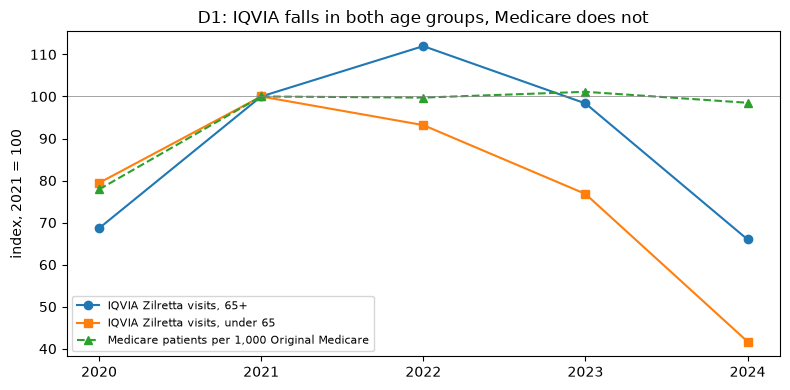

IQVIA 65+ -34.0%; IQVIA under 65 -58.3%; Medicare per 1,000 -1.5%
part (a) gap 65+ vs Medicare: -0.325 (needs abs <= 0.15) -> False
part (b) under-65 minus 65+: -0.243 (needs <= -0.15) -> True
verdict: not_supported


,"IQVIA Zilretta visits, 65+","IQVIA Zilretta visits, under 65","Medicare patients per 1,000 Original Medicare"
year,,,
2020,13650,6123,1.3
2021,19884,7708,1.7
2022,22266,7183,1.7
2023,19556,5921,1.7
2024,13122,3214,1.7


In [2]:
years = [2020, 2021, 2022, 2023, 2024]
iq = ctx["iqvia"]
med = ctx["medicare_both"].set_index("year")
series = pd.DataFrame(
    {
        "IQVIA Zilretta visits, 65+": iq["age65"].reindex(years),
        "IQVIA Zilretta visits, under 65": iq["under65"].reindex(years),
        "Medicare patients per 1,000 Original Medicare": med["benes_per_1000_ffs"].reindex(years),
    }
)
index = series / series.loc[2021] * 100
fig, ax = plt.subplots(figsize=(8, 4))
for col, style in zip(index.columns, ["o-", "s-", "^--"]):
    ax.plot(index.index, index[col], style, label=col)
ax.axhline(100, color="gray", lw=0.5)
ax.set_ylabel("index, 2021 = 100")
ax.set_xticks(years)
ax.legend(fontsize=8)
ax.set_title("D1: IQVIA falls in both age groups, Medicare does not")
plt.tight_layout()
plt.show()
d1 = result["D1"]
print(f"IQVIA 65+ {d1['chg_65']:+.1%}; IQVIA under 65 {d1['chg_under65']:+.1%}; Medicare per 1,000 {d1['chg_medicare']:+.1%}")
print(f"part (a) gap 65+ vs Medicare: {d1['gap']:+.3f} (needs abs <= {config.D1_WINDOW}) -> {d1['part_a']}")
print(f"part (b) under-65 minus 65+: {d1['under65_minus_65']:+.3f} (needs <= {-config.D1_WINDOW}) -> {d1['part_b']}")
print("verdict:", d1["verdict"])
series.round(1)

**Reading D1: not supported.** The fall *is* larger under 65 (about -58% against -34%), so part (b) holds. But IQVIA's **65+ visits also fall by about a third while Medicare's Zilretta patients per 1,000 beneficiaries are flat** (-1.5%): even in the age group Medicare covers, the two sources disagree by 32 points. The age mix therefore does not explain the gap. The result does not change at windows of 10 or 20 points, with 2022 as the base, or with Medicare's office setting only.

## 2. D2: did Zilretta move to a setting IQVIA covers poorly?

*Rule:* supported if the facility share of Medicare Zilretta services rose by 10 points or more. IQVIA's hospital share (all OA visits, not Zilretta) is context only.

In [3]:
both = ctx["medicare_both"].set_index("year")
setting = both[["facility_services", "office_services"]].copy()
setting["facility_share_%"] = setting.facility_services / (setting.facility_services + setting.office_services) * 100
setting["IQVIA hospital share of all OA visits, %"] = pd.Series(ctx["hospital"]) * 100
d2 = result["D2"]
print(f"facility share {d2['share_base']:.2%} -> {d2['share_last']:.2%}; shift {d2['shift'] * 100:+.2f} points (needs >= 10) -> {d2['verdict']}")
setting.round(2)

facility share 0.05% -> 0.09%; shift +0.04 points (needs >= 10) -> not_supported


,facility_services,office_services,facility_share_%,"IQVIA hospital share of all OA visits, %"
year,,,,
2019,4085.0,1905161.6,0.21,2.93
2020,1666.0,2645325.4,0.06,2.98
2021,1675.0,3370675.5,0.05,2.87
2022,930.0,3423954.2,0.03,2.90
2023,1485.0,3429690.2,0.04,2.91
2024,3010.0,3431291.6,0.09,3.01


**Reading D2: not supported.** Zilretta is billed almost entirely in the office setting in Medicare (a few dozen facility patients against tens of thousands), and the facility share did not move. IQVIA's market-wide hospital share is also flat. A change of setting does not explain the gap.

## 3. D3: is each visit worth more?

*Rule:* supported if company net sales **per IQVIA visit** rose by 25% or more **and** either Medicare services per patient or Medicare payment per service rose by 10% or more. Note that "sales per visit" rises almost mechanically when IQVIA visits fall, which is the thing being explained, so the Medicare condition is the informative part.

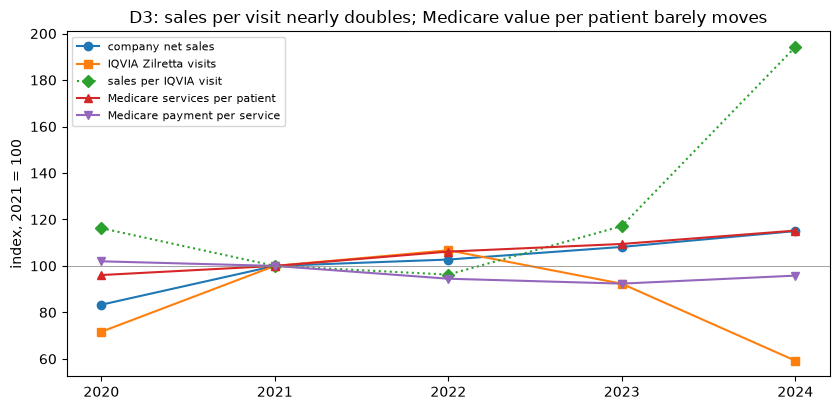

sales per IQVIA visit +94.2% (needs >= 25%)
Medicare services per patient +15.2%, payment per service -4.2% (either >= 10%)
verdict: supported
size check (added after the results, descriptive only): value per Medicare patient +10.4% against +94.2%


,company net sales,IQVIA Zilretta visits,sales per IQVIA visit,Medicare services per patient,Medicare payment per service
2020,85552000.0,19773,4326.71,60.70,14.48
2021,102700000.0,27592,3722.09,63.18,14.20
2022,105517000.0,29449,3583.04,67.07,13.42
2023,111098000.0,25478,4360.55,69.15,13.12
2024,118089000.0,16336,7228.76,72.78,13.61


In [4]:
sales = pd.Series(ctx["sales"]).reindex(years)
visits = iq["total"].reindex(years)
mm = med.reindex(years)
panel = pd.DataFrame(
    {
        "company net sales": sales,
        "IQVIA Zilretta visits": visits,
        "sales per IQVIA visit": sales / visits,
        "Medicare services per patient": mm.services / mm.benes,
        "Medicare payment per service": mm.payment_per_service,
    }
)
index = panel / panel.loc[2021] * 100
fig, ax = plt.subplots(figsize=(8.5, 4.2))
for col, style in zip(index.columns, ["o-", "s-", "D:", "^-", "v-"]):
    ax.plot(index.index, index[col], style, label=col)
ax.axhline(100, color="gray", lw=0.5)
ax.set_ylabel("index, 2021 = 100")
ax.set_xticks(years)
ax.legend(fontsize=8)
ax.set_title("D3: sales per visit nearly doubles; Medicare value per patient barely moves")
plt.tight_layout()
plt.show()
d3 = result["D3"]
size = combined_value_change(d3["services_per_patient"], d3["payment_per_service"])
print(f"sales per IQVIA visit {d3['sales_per_visit']:+.1%} (needs >= 25%)")
print(f"Medicare services per patient {d3['services_per_patient']:+.1%}, payment per service {d3['payment_per_service']:+.1%} (either >= 10%)")
print("verdict:", d3["verdict"])
print(f"size check (added after the results, descriptive only): value per Medicare patient {size:+.1%} against {d3['sales_per_visit']:+.1%}")
panel.round(2)

**Reading D3: supported on direction only, and weakly.** Sales per visit rose about 94% and Medicare services per patient rose about 15%, so the rule is met. But the Medicare measures together moved value per patient by only about 10%, roughly a ninth of the 94% needed, and with **2022 as the base year the rule is not met**. (Medicare "services" count milligram units of J3304, so services per patient is milligrams per patient; only the change matters here.) Value per visit is real in direction but cannot account for the size of the gap.

### When does the gap open? (a descriptive look, added after the results were seen)

The protocol compares two years; this table shows each year, because the two-year comparison hides the timing.

In [5]:
g = pd.read_sql(
    "select dm.year as year, sum(g.branded_injectable_visits) as zilretta, sum(g.generic_corticosteroid_visits) as steroid, sum(g.nsaid_otc_visits) as nsaid from gold_visit_share_monthly g join dim_month dm on g.month_id = dm.month_id group by 1",
    iqvia,
).set_index("year").loc[2020:2024]
timing = pd.DataFrame(
    {
        "IQVIA Zilretta visits, year on year": g.zilretta.pct_change(),
        "company net sales, year on year": pd.Series(ctx["sales"]).loc[2020:2024].pct_change(),
        "IQVIA corticosteroid visits, year on year": g.steroid.pct_change(),
        "IQVIA NSAID and OTC visits, year on year": g.nsaid.pct_change(),
    }
)
(timing.loc[2021:2024] * 100).round(1)

,"IQVIA Zilretta visits, year on year","company net sales, year on year","IQVIA corticosteroid visits, year on year","IQVIA NSAID and OTC visits, year on year"
2021,39.5,20.0,22.0,26.0
2022,6.7,2.7,7.1,16.5
2023,-13.5,5.3,-5.1,1.0
2024,-35.9,6.3,-18.3,-8.2


**Reading the timing.** Through 2022 the two sources do not diverge in size: in 2022 IQVIA visits rise about 7% and sales about 3%. The gap opens in **2023** (visits -14%, sales +5%) and is largest in **2024** (visits -36%, sales +6%). 2024 is also the year of the early-2024 dip examined in H4, when all three IQVIA categories fell (full-year 2024: corticosteroid injections -18%, NSAID and OTC -8%) and when the protocol records a claims-clearinghouse outage (from 21 February 2024). So most of the apparent divergence sits in a year where a data-capture or coverage problem is already a live possibility. This does not prove it: Zilretta fell about twice as much as the other categories, so a problem that hit everything equally would not produce the whole fall, and the timing was seen after the rules were fixed.

## 4. D4: where in IQVIA is the fall?

*Rule:* concentrated if the two groups with the largest falls account for at least 50% of the net fall in IQVIA Zilretta visits. Medicare's change in Zilretta providers in the same groups is context, with no rule.

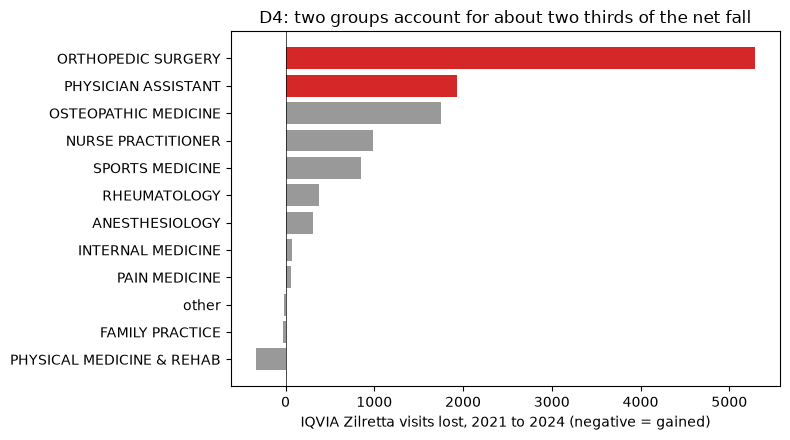

net fall 11,256; top two ['ORTHOPEDIC SURGERY', 'PHYSICIAN ASSISTANT'] = 64.2% (needs >= 50%) -> supported


,IQVIA visits lost 2021 to 2024,Medicare Zilretta providers 2021,Medicare Zilretta providers 2024
ORTHOPEDIC SURGERY,5290.0,651.0,460.0
PHYSICIAN ASSISTANT,1936.0,240.0,268.0
OSTEOPATHIC MEDICINE,1747.0,0.0,1.0
NURSE PRACTITIONER,991.0,78.0,75.0
SPORTS MEDICINE,850.0,74.0,79.0
RHEUMATOLOGY,380.0,60.0,36.0
ANESTHESIOLOGY,312.0,19.0,12.0
INTERNAL MEDICINE,68.0,15.0,10.0
PAIN MEDICINE,65.0,41.0,23.0
other,-16.0,NaN,NaN


In [6]:
d4 = result["D4"]
falls = pd.Series(d4["falls"]).sort_values(ascending=False)
prov = ctx["providers"]
table = pd.DataFrame({"IQVIA visits lost 2021 to 2024": falls})
table["Medicare Zilretta providers 2021"] = prov[config.GAP_BASE_YEAR].reindex(table.index)
table["Medicare Zilretta providers 2024"] = prov[config.GAP_LAST_YEAR].reindex(table.index)
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#d62728" if name in d4["top2"] else "#999" for name in falls.index]
ax.barh(falls.index[::-1], falls.values[::-1], color=colors[::-1])
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("IQVIA Zilretta visits lost, 2021 to 2024 (negative = gained)")
ax.set_title("D4: two groups account for about two thirds of the net fall")
plt.tight_layout()
plt.show()
print(f"net fall {int(d4['net_fall']):,}; top two {d4['top2']} = {d4['top2_share']:.1%} (needs >= 50%) -> {d4['verdict']}")
table

**Reading D4: concentrated.** Orthopedic surgery and physician assistants account for about 64% of the net fall of roughly 11,300 visits. The two sources agree in direction for orthopedic surgery (Medicare Zilretta providers fall from 651 to 460) but **not for physician assistants** (IQVIA visits fall by about 1,900 while Medicare providers rise from 240 to 268). That is where the sources diverge most, and the most useful place to ask IQVIA about panel coverage.

## 5. Does the threshold matter? Sensitivity

Each verdict is shown at the neighbouring thresholds of the grid fixed in the protocol (the primary setting is the middle one), with 2022 as the base year and, for D1 and D3, Medicare's office setting only.

In [7]:
rows = []
for check, info in sens.items():
    rows.append(
        {
            "check": check,
            "grid verdicts (low, primary, high)": " / ".join(v for _, v in info["grid"]),
            "changes across grid": info["flips"],
            "base year 2022": info["alt_base"],
            "Medicare office only": info["office_only"],
        }
    )
pd.DataFrame(rows)

,check,"grid verdicts (low, primary, high)",changes across grid,base year 2022,Medicare office only
0,D1,not_supported / not_supported / not_supported,False,not_supported,not_supported
1,D2,not_supported / not_supported / not_supported,False,not_supported,NaN
2,D3,supported / supported / supported,False,not_supported,supported
3,D4,supported / supported / supported,False,supported,NaN


Only one result is fragile: **D3 is not supported when 2022 is the base year**. D1, D2 and D4 do not change anywhere on the grid. That is a further reason to read the overall "supported" (which comes from D3 alone) as weak.

## 6. What this means

| | Result | What to take from it |
|---|---|---|
| D1 population | not supported | even IQVIA's 65+ visits fall by a third while Medicare patients per 1,000 are flat |
| D2 setting | not supported | Zilretta is an office product in Medicare and the share did not move |
| D3 value per visit | supported on direction only | explains about a ninth of the size; fails with 2022 as base |
| D4 concentration | concentrated | orthopedic surgery and physician assistants, about 64% of the net fall; the sources diverge for physician assistants |
| Overall (any of D1 to D3) | supported, via D3 only | **no tested explanation accounts for the size of the gap** |

**What this does not say.** It does not say IQVIA is wrong or that Zilretta's use did not fall. It says the public data we hold cannot account for a fall of this size while company sales rose. Explanations that need company data (inventory, gross-to-net adjustments, channel mix) are untestable here, and a change in the panel's coverage of Zilretta settings or specialties is the leading open possibility; **none of these is tested**. The size of the IQVIA decline should not be quoted as a market fact until IQVIA is asked about coverage.

In [8]:
# Reproducibility: the final run was done twice; the two verdict tables are identical.
runs = pd.read_sql("select distinct run_id from gold_ext_verdicts where check_id = 'GAP' order by run_id", ext).run_id.tolist()
a, b = runs[-2], runs[-1]
cols = "check_id, metric, value, verdict, note"
ta = pd.read_sql(f"select {cols} from gold_ext_verdicts where run_id = '{a}' and check_id in ('D1','D2','D3','D4','GAP') order by check_id, metric", ext)
tb = pd.read_sql(f"select {cols} from gold_ext_verdicts where run_id = '{b}' and check_id in ('D1','D2','D3','D4','GAP') order by check_id, metric", ext)
print(a, b, "identical:", ta.equals(tb), "rows:", len(ta))

20261008T124808Z-54071f4 20261008T124815Z-54071f4 identical: True rows: 10
